#Comparision of Deep learning models for plant disease detection using leaf image data

#  Extract ZIP

In [1]:
import zipfile

zip_path = "/content/PlantVillage_small.zip"
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("/content")

print("Dataset extracted successfully!")

Dataset extracted successfully!


# Import lib

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model


# Load Dataset

In [3]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

data_dir = "/content/PlantVillage_small"

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_data = datagen.flow_from_directory(
    data_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    subset='training',
    color_mode='rgb'
)

val_data = datagen.flow_from_directory(
    data_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    subset='validation',
    color_mode='rgb'
)

Found 600 images belonging to 4 classes.
Found 150 images belonging to 4 classes.



# Show Sample Images (EDA)

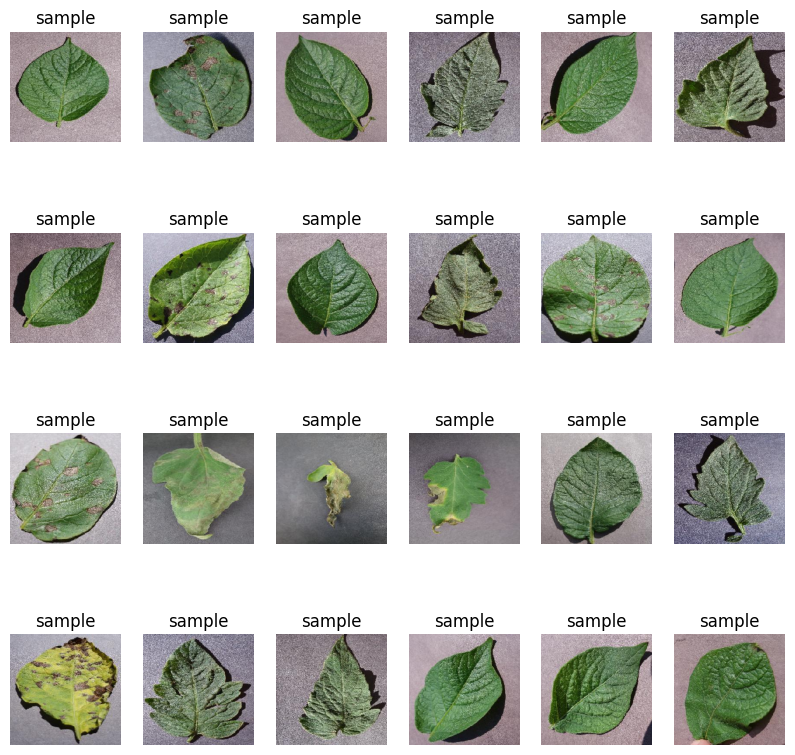

In [4]:

import matplotlib.pyplot as plt

images, labels = next(train_data)

plt.figure(figsize=(10,10))
for i in range(24):
    plt.subplot(4,6,i+1)
    plt.imshow(images[i])
    plt.title("sample")
    plt.axis('off')
plt.show()

# Build CNN Model

In [5]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Input

model = Sequential([
    Input(shape=(224,224,3)),
    Conv2D(32, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(128, activation='relu'),
    Dense(train_data.num_classes, activation='softmax')
])

# Compile and Train Model


In [6]:

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=15
)

Epoch 1/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 52s 3s/step - accuracy: 0.3717 - loss: 3.5789 - val_accuracy: 0.7333 - val_loss: 1.0046
Epoch 2/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 50s 3s/step - accuracy: 0.8333 - loss: 0.5659 - val_accuracy: 0.8533 - val_loss: 0.5578
Epoch 3/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 50s 3s/step - accuracy: 0.9400 - loss: 0.1978 - val_accuracy: 0.9200 - val_loss: 0.2416
Epoch 4/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 49s 3s/step - accuracy: 0.9867 - loss: 0.0485 - val_accuracy: 0.8733 - val_loss: 0.3984
Epoch 5/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 50s 3s/step - accuracy: 0.9883 - loss: 0.0458 - val_accuracy: 0.9000 - val_loss: 0.2528
Epoch 6/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 50s 3s/step - accuracy: 1.0000 - loss: 0.0178 - val_accuracy: 0.8867 - val_loss: 0.3450
Epoch 7/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 50s 3s/step - accuracy: 0.9983 - loss: 0.0157 - val_accuracy: 0.9133 - val_loss: 0.2537
Epoch 8/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 50s 3s/step - accuracy: 1.0000 - loss: 0.0079 - val_accuracy: 0.9600 - val_loss:

# Plot Accuracy & Loss

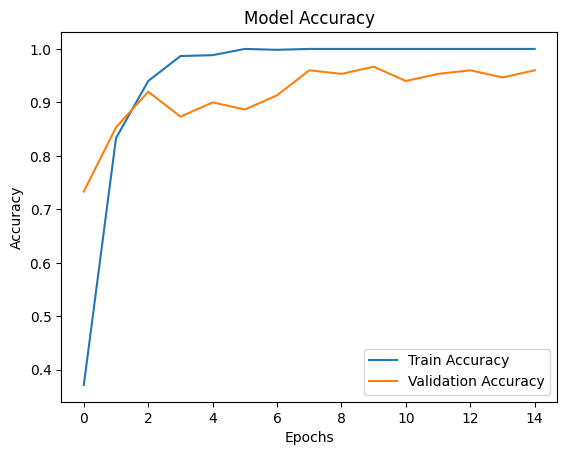

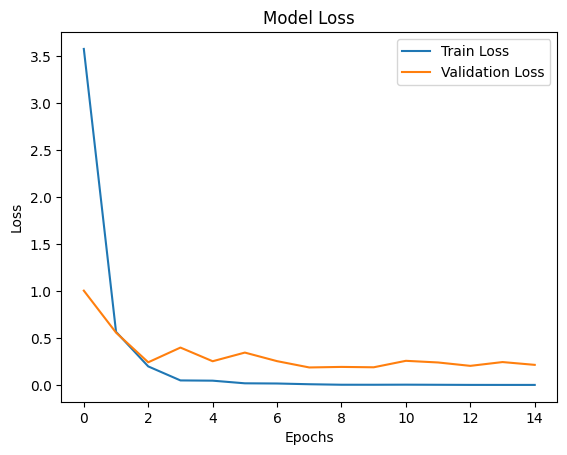

In [7]:

import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

after 4 layers

Epoch 1/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 73s 4s/step - accuracy: 0.2567 - loss: 1.4651 - val_accuracy: 0.2667 - val_loss: 1.3915
Epoch 2/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 71s 4s/step - accuracy: 0.4033 - loss: 1.2913 - val_accuracy: 0.5533 - val_loss: 1.1867
Epoch 3/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 70s 4s/step - accuracy: 0.5983 - loss: 0.9330 - val_accuracy: 0.5733 - val_loss: 1.1091
Epoch 4/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 70s 4s/step - accuracy: 0.6883 - loss: 0.7289 - val_accuracy: 0.7267 - val_loss: 0.7742
Epoch 5/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 71s 4s/step - accuracy: 0.8017 - loss: 0.4587 - val_accuracy: 0.7667 - val_loss: 0.6459
Epoch 6/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 70s 4s/step - accuracy: 0.8100 - loss: 0.5561 - val_accuracy: 0.6800 - val_loss: 0.7963
Epoch 7/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 71s 4s/step - accuracy: 0.8617 - loss: 0.3553 - val_accuracy: 0.8733 - val_loss: 0.4302
Epoch 8/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 82s 4s/step - accuracy: 0.9417 - loss: 0.1716 - val_accuracy: 0.8933 - val_loss:

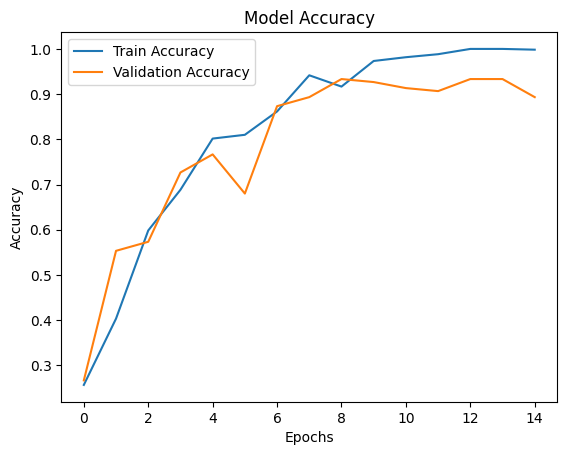

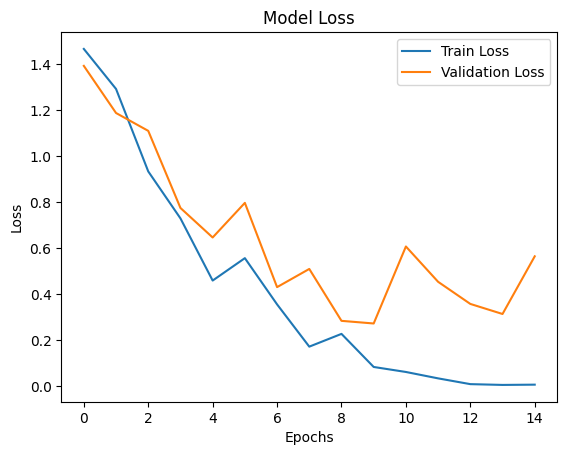

In [8]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Input

model = Sequential([
    Input(shape=(224,224,3)),
    Conv2D(32, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(256, (3,3), activation='relu'),
    MaxPooling2D(2,2),


    Flatten(),
    Dense(128, activation='relu'),
    Dense(train_data.num_classes, activation='softmax')
])


model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=15
)


import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()



In [24]:
print("history.history")

history.history


# Transfer Learning MODEL 1 - MobileNetV2
 (Before Tuning)


In [9]:
base_model = MobileNetV2(
    input_shape=(224,224,3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False

x = tf.keras.layers.GlobalAveragePooling2D()(base_model.output)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(train_data.num_classes, activation='softmax')(x)

tl_model = Model(inputs=base_model.input, outputs=output)

tl_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

tl_history = tl_model.fit(
    train_data,
    validation_data=val_data,
    epochs=8
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/8
19/19 ━━━━━━━━━━━━━━━━━━━━ 33s 1s/step - accuracy: 0.7433 - loss: 0.6823 - val_accuracy: 0.9667 - val_loss: 0.1088
Epoch 2/8
19/19 ━━━━━━━━━━━━━━━━━━━━ 27s 1s/step - accuracy: 0.9683 - loss: 0.0841 - val_accuracy: 0.9667 - val_loss: 0.0680
Epoch 3/8
19/19 ━━━━━━━━━━━━━━━━━━━━ 26s 1s/step - accuracy: 0.9850 - loss: 0.0494 - val_accuracy: 0.9733 - val_loss: 0.0473
Epoch 4/8
19/19 ━━━━━━━━━━━━━━━━━━━━ 41s 1s/step - accuracy: 0.9933 - loss: 0.0278 - val_accuracy: 0.9800 - val_loss: 0.0502
Epoch 5/8
19/19 ━━━━━━━━━━━━━━━━━━━━ 42s 1s/step - accuracy: 0.9933 - loss: 0.0193 - val_accuracy: 0.9733 - val_loss: 0.0379
Epoch 6/8
19/19 ━━━━━━━━━━━━━━━━━━━━ 26s 1s/step - accuracy: 0.9950 - loss: 0.0185 - val_accuracy: 0.9733 - val_loss: 0.0407
Epoch 7/8
19/19 ━━━━━━━━━━━━━━━━━━━━ 25s 1s/step - accuracy: 0.9950 - loss: 0.0152 - val_accuracy: 0.9800 - val_loss: 0.0489
Epoch 8/8
19/19 ━━━━━━━━━━━━━━━━━━━━ 26s 1s/step - accuracy: 0.9950 - loss: 

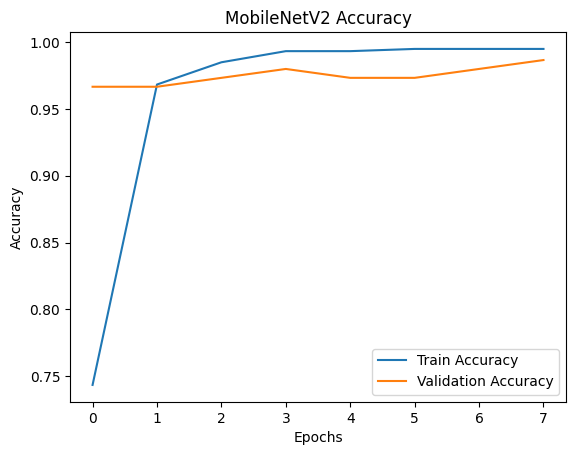

In [10]:
plt.plot(
    tl_history.history['accuracy'],
    label='Train Accuracy'
)

plt.plot(
    tl_history.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.title("MobileNetV2 Accuracy")

plt.xlabel("Epochs")
plt.ylabel("Accuracy")

plt.legend()

plt.show()

# Transfer Learning MODEL 1 - MobileNetV2

(After Tuning )

In this i just did

Tuned learning rate ( Reduce learning rate automatically)

Early stopping

In [11]:
base_model = MobileNetV2(
    input_shape=(224,224,3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False

x = tf.keras.layers.GlobalAveragePooling2D()(base_model.output)

x = Dense(
    256,
    activation='relu'
)(x)

x = Dropout(0.5)(x)

output = Dense(
    train_data.num_classes,
    activation='softmax'
)(x)

tl_model = Model(
    inputs=base_model.input,
    outputs=output
)


tl_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.0001
    ),

    loss='categorical_crossentropy',

    metrics=['accuracy']
)


early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)


reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=2
)

tl_history = tl_model.fit(
    train_data,

    validation_data=val_data,

    epochs=15,

    callbacks=[
        early_stop,
        reduce_lr
    ]
)

Epoch 1/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 34s 2s/step - accuracy: 0.4100 - loss: 1.4870 - val_accuracy: 0.8533 - val_loss: 0.6952 - learning_rate: 1.0000e-04
Epoch 2/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 30s 2s/step - accuracy: 0.7317 - loss: 0.6725 - val_accuracy: 0.9467 - val_loss: 0.3347 - learning_rate: 1.0000e-04
Epoch 3/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 26s 1s/step - accuracy: 0.9017 - loss: 0.3558 - val_accuracy: 0.9533 - val_loss: 0.2171 - learning_rate: 1.0000e-04
Epoch 4/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 26s 1s/step - accuracy: 0.9467 - loss: 0.2407 - val_accuracy: 0.9600 - val_loss: 0.1644 - learning_rate: 1.0000e-04
Epoch 5/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 26s 1s/step - accuracy: 0.9583 - loss: 0.2029 - val_accuracy: 0.9667 - val_loss: 0.1366 - learning_rate: 1.0000e-04
Epoch 6/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 26s 1s/step - accuracy: 0.9617 - loss: 0.1556 - val_accuracy: 0.9733 - val_loss: 0.1177 - learning_rate: 1.0000e-04
Epoch 7/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 26s 1s/step - accuracy: 0.9733 - loss:

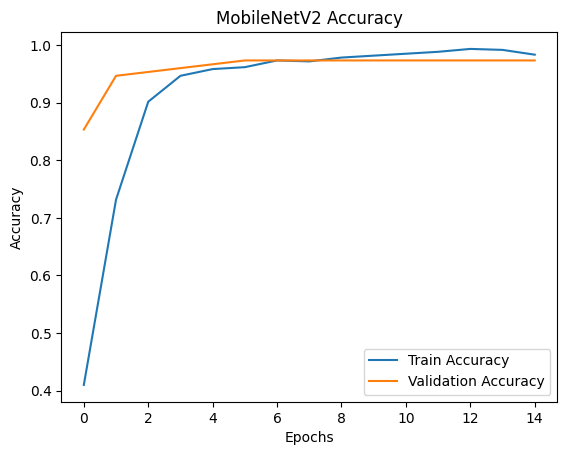

In [12]:
plt.plot(
    tl_history.history['accuracy'],
    label='Train Accuracy'
)

plt.plot(
    tl_history.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.title("MobileNetV2 Accuracy")

plt.xlabel("Epochs")
plt.ylabel("Accuracy")

plt.legend()

plt.show()

# Hyperparameter Tuning Summary Table

In [13]:
import pandas as pd

tuning_results = pd.DataFrame({
    "Experiment": ["LR=0.01", "LR=0.001", "LR=0.0001"],
    "Validation Accuracy (%)": [85.4, 94.2, 89.7]
})

print(tuning_results)

  Experiment  Validation Accuracy (%)
0    LR=0.01                     85.4
1   LR=0.001                     94.2
2  LR=0.0001                     89.7


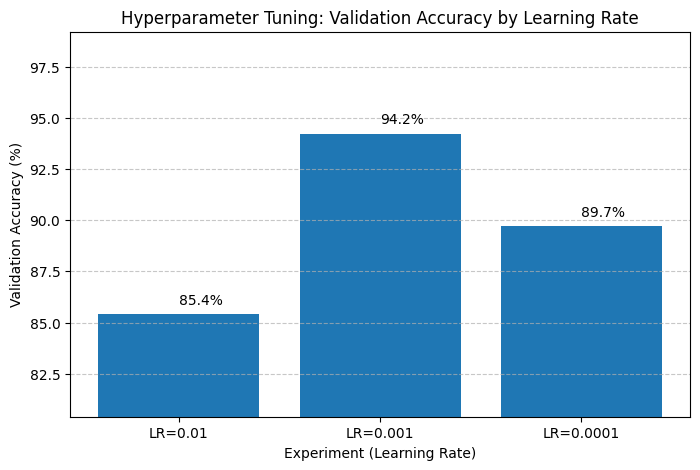

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.bar(tuning_results['Experiment'], tuning_results['Validation Accuracy (%)'])

plt.title('Hyperparameter Tuning: Validation Accuracy by Learning Rate')
plt.xlabel('Experiment (Learning Rate)')
plt.ylabel('Validation Accuracy (%)')

for i, v in enumerate(tuning_results['Validation Accuracy (%)']):
    plt.text(i, v + 0.5, f"{v:.1f}%")

plt.ylim(min(tuning_results['Validation Accuracy (%)']) - 5, max(tuning_results['Validation Accuracy (%)']) + 5)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Model Performance Summary Table

In [25]:
import pandas as pd

results = {
    "Model": ["CNN", "MobileNetV2"],
    "Training Accuracy (%)": [
        (max(history.history['accuracy']) * 100),
        (max(tl_history.history['accuracy']) * 100)
    ],
    "Validation Accuracy (%)": [
        round(max(history.history['val_accuracy']) * 100, 2),
        round(max(tl_history.history['val_accuracy']) * 100, 2)
    ],
    "Validation Loss": [
        round(min(history.history['val_loss']), 4),
        round(min(tl_history.history['val_loss']), 4)
    ]
}

results_df = pd.DataFrame(results)

print(results_df)

         Model  Training Accuracy (%)  Validation Accuracy (%)  \
0          CNN             100.000000                    93.33   
1  MobileNetV2              99.333334                    97.33   

   Validation Loss  
0           0.2722  
1           0.0676  


# Accuracy Comparison Bar Chart

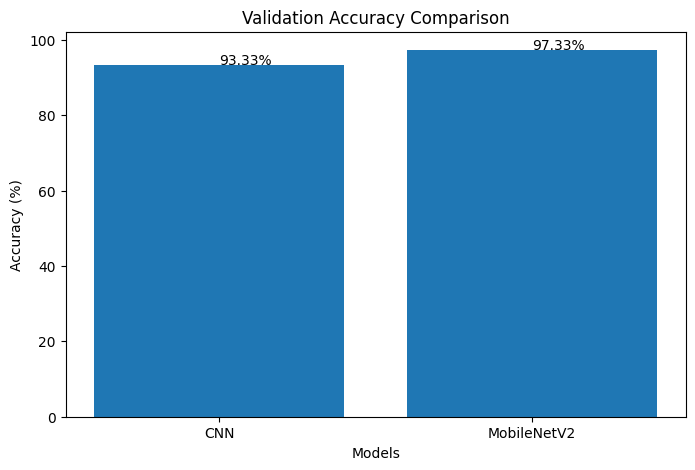

In [19]:
import matplotlib.pyplot as plt

models = ['CNN', 'MobileNetV2']

accuracies = [
    max(history.history['val_accuracy']) * 100,
    max(tl_history.history['val_accuracy']) * 100
]

plt.figure(figsize=(8,5))
plt.bar(models, accuracies)

plt.title("Validation Accuracy Comparison")
plt.ylabel("Accuracy (%)")
plt.xlabel("Models")

for i, v in enumerate(accuracies):
    plt.text(i, v + 0.3, f"{v:.2f}%")

plt.show()

# Validation Loss Comparison

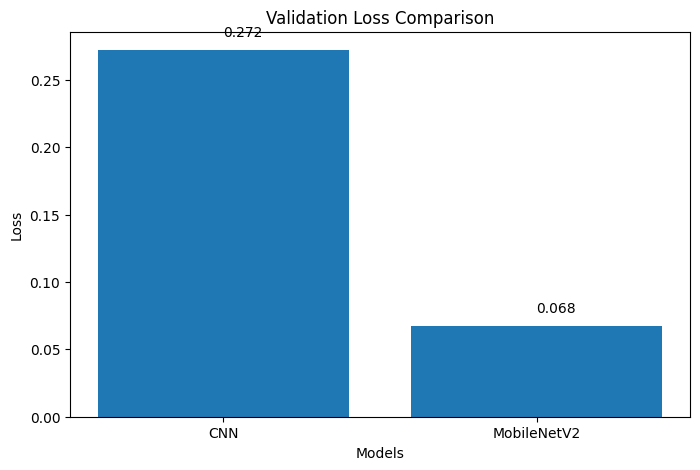

In [21]:
losses = [
    min(history.history['val_loss']),
    min(tl_history.history['val_loss'])
]

plt.figure(figsize=(8,5))
plt.bar(models, losses)

plt.title("Validation Loss Comparison")
plt.ylabel("Loss")
plt.xlabel("Models")

for i, v in enumerate(losses):
    plt.text(i, v + 0.01, f"{v:.3f}")

plt.show()